<a href="https://colab.research.google.com/github/Nida682/Genetic-Algorithm/blob/main/herbal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
import shutil

# ==========================================
# PART 1: SETUP KAGGLE CREDENTIALS
# ==========================================
!pip install -q kaggle

# Using your provided credentials
api_token = {"username":"maylo.ml","key":"db3a00a2f4901872d99912832c8af078"}

!mkdir -p ~/.kaggle
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle authentication configured!")

# ==========================================
# PART 2: DOWNLOAD & EXTRACT DATASET
# ==========================================
dataset_id = "jaydepaolomirandilla/philippine-medicinal-plant-leaf-dataset"

# Clean up old data to ensure a fresh start
if os.path.exists('dataset'):
    shutil.rmtree('dataset')

print(f"⬇️ Downloading {dataset_id}...")
!kaggle datasets download -d {dataset_id}

print("📦 Extracting files...")
!mkdir -p dataset
!unzip -q philippine-medicinal-plant-leaf-dataset.zip -d dataset/
!rm philippine-medicinal-plant-leaf-dataset.zip

# ==========================================
# PART 3: DYNAMIC PATH VERIFICATION
# ==========================================
# This loop finds the deep folder that actually contains the plant subdirectories
DATA_DIR = 'dataset/'
for root, dirs, files in os.walk('dataset'):
    if len(dirs) >= 40:
        DATA_DIR = root
        break

print(f"\n✅ Setup Complete!")
print(f"📍 Data Path: {DATA_DIR}")
categories = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"🌿 Detected {len(categories)} Herbal Classes.")

✅ Kaggle authentication configured!
⬇️ Downloading jaydepaolomirandilla/philippine-medicinal-plant-leaf-dataset...
Dataset URL: https://www.kaggle.com/datasets/jaydepaolomirandilla/philippine-medicinal-plant-leaf-dataset
License(s): other
100% 7.45G/7.45G [01:42<00:00, 78.4MB/s]

📦 Extracting files...

✅ Setup Complete!
📍 Data Path: dataset/Philippine Medicinal Plant Leaf Dataset
🌿 Detected 40 Herbal Classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the split here
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # THIS IS THE SPLIT (80% Train, 20% Val)
)

# 2. Load and Split
train_generator = datagen.flow_from_directory(
    'dataset/Philippine Medicinal Plant Leaf Dataset',
    subset='training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    'dataset/Philippine Medicinal Plant Leaf Dataset',
    subset='validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# 3. Now Perform the Count
train_count = train_generator.samples
val_count = validation_generator.samples
total_count = train_count + val_count

print(f"\n--- DATASET SPLIT SUCCESSFUL ---")
print(f"Total Images: {total_count}")
print(f"Training Set (80%): {train_count}")
print(f"Validation Set (20%): {val_count}")

# 4. Count per class (for Section IV of your Thesis)
import numpy as np
print(f"\n--- CLASS DISTRIBUTION (Training Set) ---")
class_indices = train_generator.class_indices
for class_name, idx in class_indices.items():
    # Count occurrences in this specific generator
    count = np.sum(train_generator.classes == idx)
    print(f"{class_name:25} | Train Count: {count}")

Found 3983 images belonging to 40 classes.
Found 988 images belonging to 40 classes.

--- DATASET SPLIT SUCCESSFUL ---
Total Images: 4971
Training Set (80%): 3983
Validation Set (20%): 988

--- CLASS DISTRIBUTION (Training Set) ---
10Coleus scutellarioides(CS) | Train Count: 96
11Phyllanthus niruri(PN)  | Train Count: 104
12Corchorus olitorius(CO) | Train Count: 114
13Momordica charantia (MC) | Train Count: 85
14Euphorbia hirta(EH)     | Train Count: 103
15Curcuma longa(CL)       | Train Count: 80
16Carmona retusa(CR)      | Train Count: 104
17Senna alata(SA)         | Train Count: 95
18Mentha cordifolia Opiz(MCO) | Train Count: 80
19Capsicum frutescens(CF) | Train Count: 101
1Hibiscus rosa-sinensis(HRS) | Train Count: 93
20Jatropha curcas(JC)     | Train Count: 114
21Ocimum basilicum(OB)    | Train Count: 119
22Nerium oleander(NO)     | Train Count: 104
23Pandanus amaryllifolius(PA) | Train Count: 87
24Aloe barbadensis Miller(ABM) | Train Count: 104
25Lagerstroemia speciosa(LS) | Trai

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# PART 4: DATA GENERATORS (CLIENT-READY)
# ==========================================

# Using 'DATA_DIR' from your successful verification step
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90,       # Handles leaves at any angle
    width_shift_range=0.2,   # Handles off-center leaves
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.5,           # CRITICAL: Forces model to look at texture in blurry images
    brightness_range=[0.5, 1.5], # Handles different garden lighting
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2     # 80% Train, 20% Validation
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,                # Using the verified path from Step 1
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(f"✅ Ready! Found {train_gen.samples} training images and {val_gen.samples} validation images.")

Found 3983 images belonging to 40 classes.
Found 988 images belonging to 40 classes.
✅ Ready! Found 3983 training images and 988 validation images.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# ==========================================
# PART 5: MODEL ARCHITECTURE
# ==========================================

# 1. Load the pre-trained MobileNetV2 base
# We 'freeze' it initially to keep the general features learned from ImageNet
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# 2. Add custom layers for your 40 Philippine medicinal plants
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Crucial for Latin Honors quality: prevents overfitting
    layers.Dense(train_gen.num_classes, activation='softmax')
])

# 3. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │        20,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,934,376 (11.19 MB)

 Trainable params: 676,392 (2.58 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ==========================================
# PART 6: MODEL TRAINING (BEST MODEL SAVER)
# ==========================================

# 1. Early Stopping: Stops training if the model stops getting better
# This prevents 'memorizing' the blurry images (overfitting)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,             # If no improvement for 3 epochs, stop
    restore_best_weights=True
)

# 2. Checkpoint: Saves only the version with the highest validation accuracy
checkpoint = ModelCheckpoint(
    'herbal_ph_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 3. Start Training
print("🚀 Training starting... Grab a coffee, this may take a while!")
history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // train_gen.batch_size,
    validation_data=val_gen,
    validation_steps=val_gen.samples // val_gen.batch_size,
    epochs=15, # 15 is a good balance for MobileNetV2
    callbacks=[early_stop, checkpoint]
)

print("\n✅ Training Complete!")
print("Best model is saved as: 'herbal_ph_best_model.h5'")

🚀 Training starting... Grab a coffee, this may take a while!
Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3615 - loss: 2.5185
Epoch 1: val_accuracy improved from None to 0.83854, saving model to herbal_ph_best_model.h5



Epoch 1: finished saving model to herbal_ph_best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 680s 5s/step - accuracy: 0.5467 - loss: 1.6579 - val_accuracy: 0.8385 - val_loss: 0.6258
Epoch 2/15
  1/124 ━━━━━━━━━━━━━━━━━━━━ 5:55 3s/step - accuracy: 0.7812 - loss: 0.8487

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.83854
124/124 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7812 - loss: 0.8487 - val_accuracy: 0.8271 - val_loss: 0.6396
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7782 - loss: 0.7486
Epoch 3: val_accuracy improved from 0.83854 to 0.87292, saving model to herbal_ph_best_model.h5



Epoch 3: finished saving model to herbal_ph_best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 686s 6s/step - accuracy: 0.7942 - loss: 0.6809 - val_accuracy: 0.8729 - val_loss: 0.4126
Epoch 4/15
  1/124 ━━━━━━━━━━━━━━━━━━━━ 3:53 2s/step - accuracy: 0.7188 - loss: 0.7667
Epoch 4: val_accuracy improved from 0.87292 to 0.88750, saving model to herbal_ph_best_model.h5



Epoch 4: finished saving model to herbal_ph_best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.7188 - loss: 0.7667 - val_accuracy: 0.8875 - val_loss: 0.4029
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8397 - loss: 0.5415
Epoch 5: val_accuracy improved from 0.88750 to 0.89167, saving model to herbal_ph_best_model.h5



Epoch 5: finished saving model to herbal_ph_best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 673s 5s/step - accuracy: 0.8436 - loss: 0.5191 - val_accuracy: 0.8917 - val_loss: 0.3721
Epoch 6/15
  1/124 ━━━━━━━━━━━━━━━━━━━━ 4:57 2s/step - accuracy: 0.8438 - loss: 0.5368
Epoch 6: val_accuracy did not improve from 0.89167
124/124 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.8438 - loss: 0.5368 - val_accuracy: 0.8885 - val_loss: 0.3571
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8514 - loss: 0.4561
Epoch 7: val_accuracy did not improve from 0.89167
124/124 ━━━━━━━━━━━━━━━━━━━━ 649s 5s/step - accuracy: 0.8535 - loss: 0.4496 - val_accuracy: 0.8906 - val_loss: 0.3516
Epoch 8/15
  1/124 ━━━━━━━━━━━━━━━━━━━━ 4:14 2s/step - accuracy: 0.8750 - loss: 0.3036
Epoch 8: val_accuracy did not improve from 0.89167
124/124 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.8750 - loss: 0.3036 - val_accuracy: 0.8875 - val_loss: 0.3650
Epoch 9/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accu


Epoch 9: finished saving model to herbal_ph_best_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 651s 5s/step - accuracy: 0.8742 - loss: 0.3865 - val_accuracy: 0.9219 - val_loss: 0.2548
Epoch 10/15
  1/124 ━━━━━━━━━━━━━━━━━━━━ 4:37 2s/step - accuracy: 0.9375 - loss: 0.1643
Epoch 10: val_accuracy did not improve from 0.92188
124/124 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.9375 - loss: 0.1643 - val_accuracy: 0.9115 - val_loss: 0.2945
Epoch 11/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8916 - loss: 0.3390
Epoch 11: val_accuracy did not improve from 0.92188
124/124 ━━━━━━━━━━━━━━━━━━━━ 708s 6s/step - accuracy: 0.8929 - loss: 0.3403 - val_accuracy: 0.9146 - val_loss: 0.2621
Epoch 12/15
  1/124 ━━━━━━━━━━━━━━━━━━━━ 4:14 2s/step - accuracy: 0.9375 - loss: 0.1129
Epoch 12: val_accuracy did not improve from 0.92188
124/124 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9375 - loss: 0.1129 - val_accuracy: 0.9146 - val_loss: 0.2565

✅ Training Complete!
Best model is saved as: 'herb

In [ ]:
import tensorflow as tf

# 1. Load your existing best model
model = tf.keras.models.load_model('herbal_ph_best_model.h5')

# 2. Re-convert with SELECT_TF_OPS enabled for better compatibility
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# This flag helps resolve version mismatches by including standard ops
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, # Standard TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS   # Flex ops for compatibility
]

# Optimize for mobile but keep versions stable
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# 3. Save as a new file
with open('herbal_model_v2.tflite', 'wb') as f:
    f.write(tflite_model)

from google.colab import files
files.download('herbal_model_v2.tflite')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'herbal_ph_best_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import tensorflow as tf
from google.colab import files
import re

# 1. Convert the model to TFLite format
print("🔄 Converting model to TFLite...")
model = tf.keras.models.load_model('herbal_ph_best_model.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Optimized for mobile speed
tflite_model = converter.convert()

# 2. Save the TFLite model file
with open('herbal_model.tflite', 'wb') as f:
    f.write(tflite_model)

# 3. Clean the labels (Removes the first digit/numbering)
# Example: '20Jatropha curcas' becomes 'Jatropha curcas'
print("📝 Cleaning labels...")
class_names = sorted(train_gen.class_indices.keys())

with open('labels.txt', 'w') as f:
    for name in class_names:
        # regex removes leading digits at the start of the string
        clean_name = re.sub(r'^\d+', '', name)
        f.write(clean_name + '\n')

print("✅ Files prepared. Starting download...")

# 4. Trigger download for both files
files.download('herbal_model.tflite')
files.download('labels.txt')


🔄 Converting model to TFLite...


Saved artifact at '/tmp/tmpxqhhftbu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 40), dtype=tf.float32, name=None)
Captures:
  138652970197328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970200400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970200592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970201168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970199632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970197712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970200208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970200016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970201360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970196752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138652970195

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

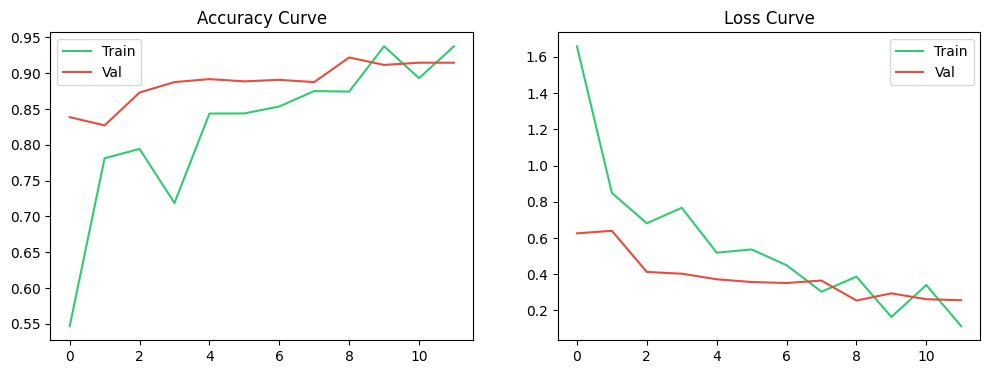

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


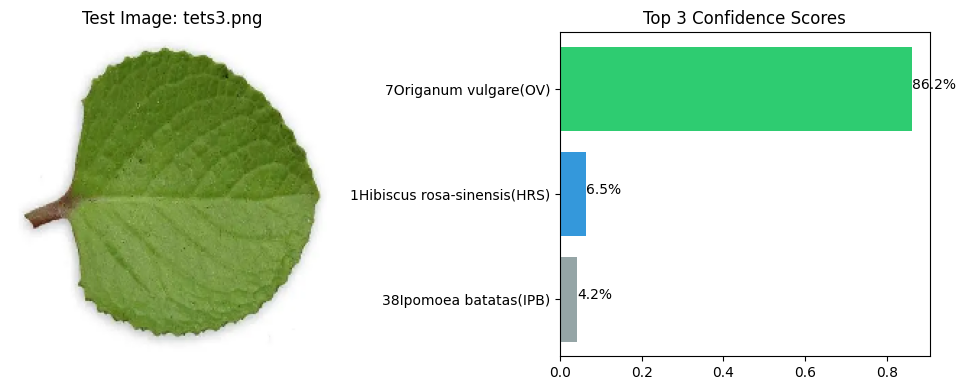

31/31 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step

      FINAL SYSTEM METRICS
Overall Accuracy: 2.94%
Precision Score:  2.90%
Recall Score:     2.94%
F1-Score:         2.90%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import tensorflow as tf

# ==========================================
# 1. THE ESSENTIAL GRAPHS (HISTORY)
# ==========================================
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train', color='#2ecc71')
    plt.plot(history.history['val_accuracy'], label='Val', color='#e74c3c')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train', color='#2ecc71')
    plt.plot(history.history['val_loss'], label='Val', color='#e74c3c')
    plt.title('Loss Curve')
    plt.legend()
    plt.show()

# ==========================================
# 2. TOP-3 PREDICTION CHART (Using tets3.png)
# ==========================================
def plot_top_3_demo(model, img_path, class_names):
    # Load and preprocess
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    preds = model.predict(img_array)[0]
    top_3_idx = np.argsort(preds)[-3:][::-1]

    plt.figure(figsize=(10, 4))

    # Show Image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Test Image: tets3.png")

    # Show Bar Chart
    plt.subplot(1, 2, 2)
    labels = [class_names[i] for i in top_3_idx]
    values = [preds[i] for i in top_3_idx]

    bars = plt.barh(labels, values, color=['#2ecc71', '#3498db', '#95a5a6'])
    plt.gca().invert_yaxis()
    plt.title('Top 3 Confidence Scores')

    for bar in bars:
        plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width()*100:.1f}%')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. GLOBAL METRICS (The "Small" Confusion Matrix Alternative)
# ==========================================
def show_summary_stats(model, val_gen):
    val_gen.reset()
    Y_pred = model.predict(val_gen)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = val_gen.classes

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    print("\n" + "="*30)
    print("      FINAL SYSTEM METRICS")
    print("="*30)
    print(f"Overall Accuracy: {acc*100:.2f}%")
    print(f"Precision Score:  {prec*100:.2f}%")
    print(f"Recall Score:     {rec*100:.2f}%")
    print(f"F1-Score:         {f1*100:.2f}%")
    print("="*30)

# --- EXECUTE ---
plot_history(history)
plot_top_3_demo(model, 'tets3.png', list(train_gen.class_indices.keys()))
show_summary_stats(model, val_gen)

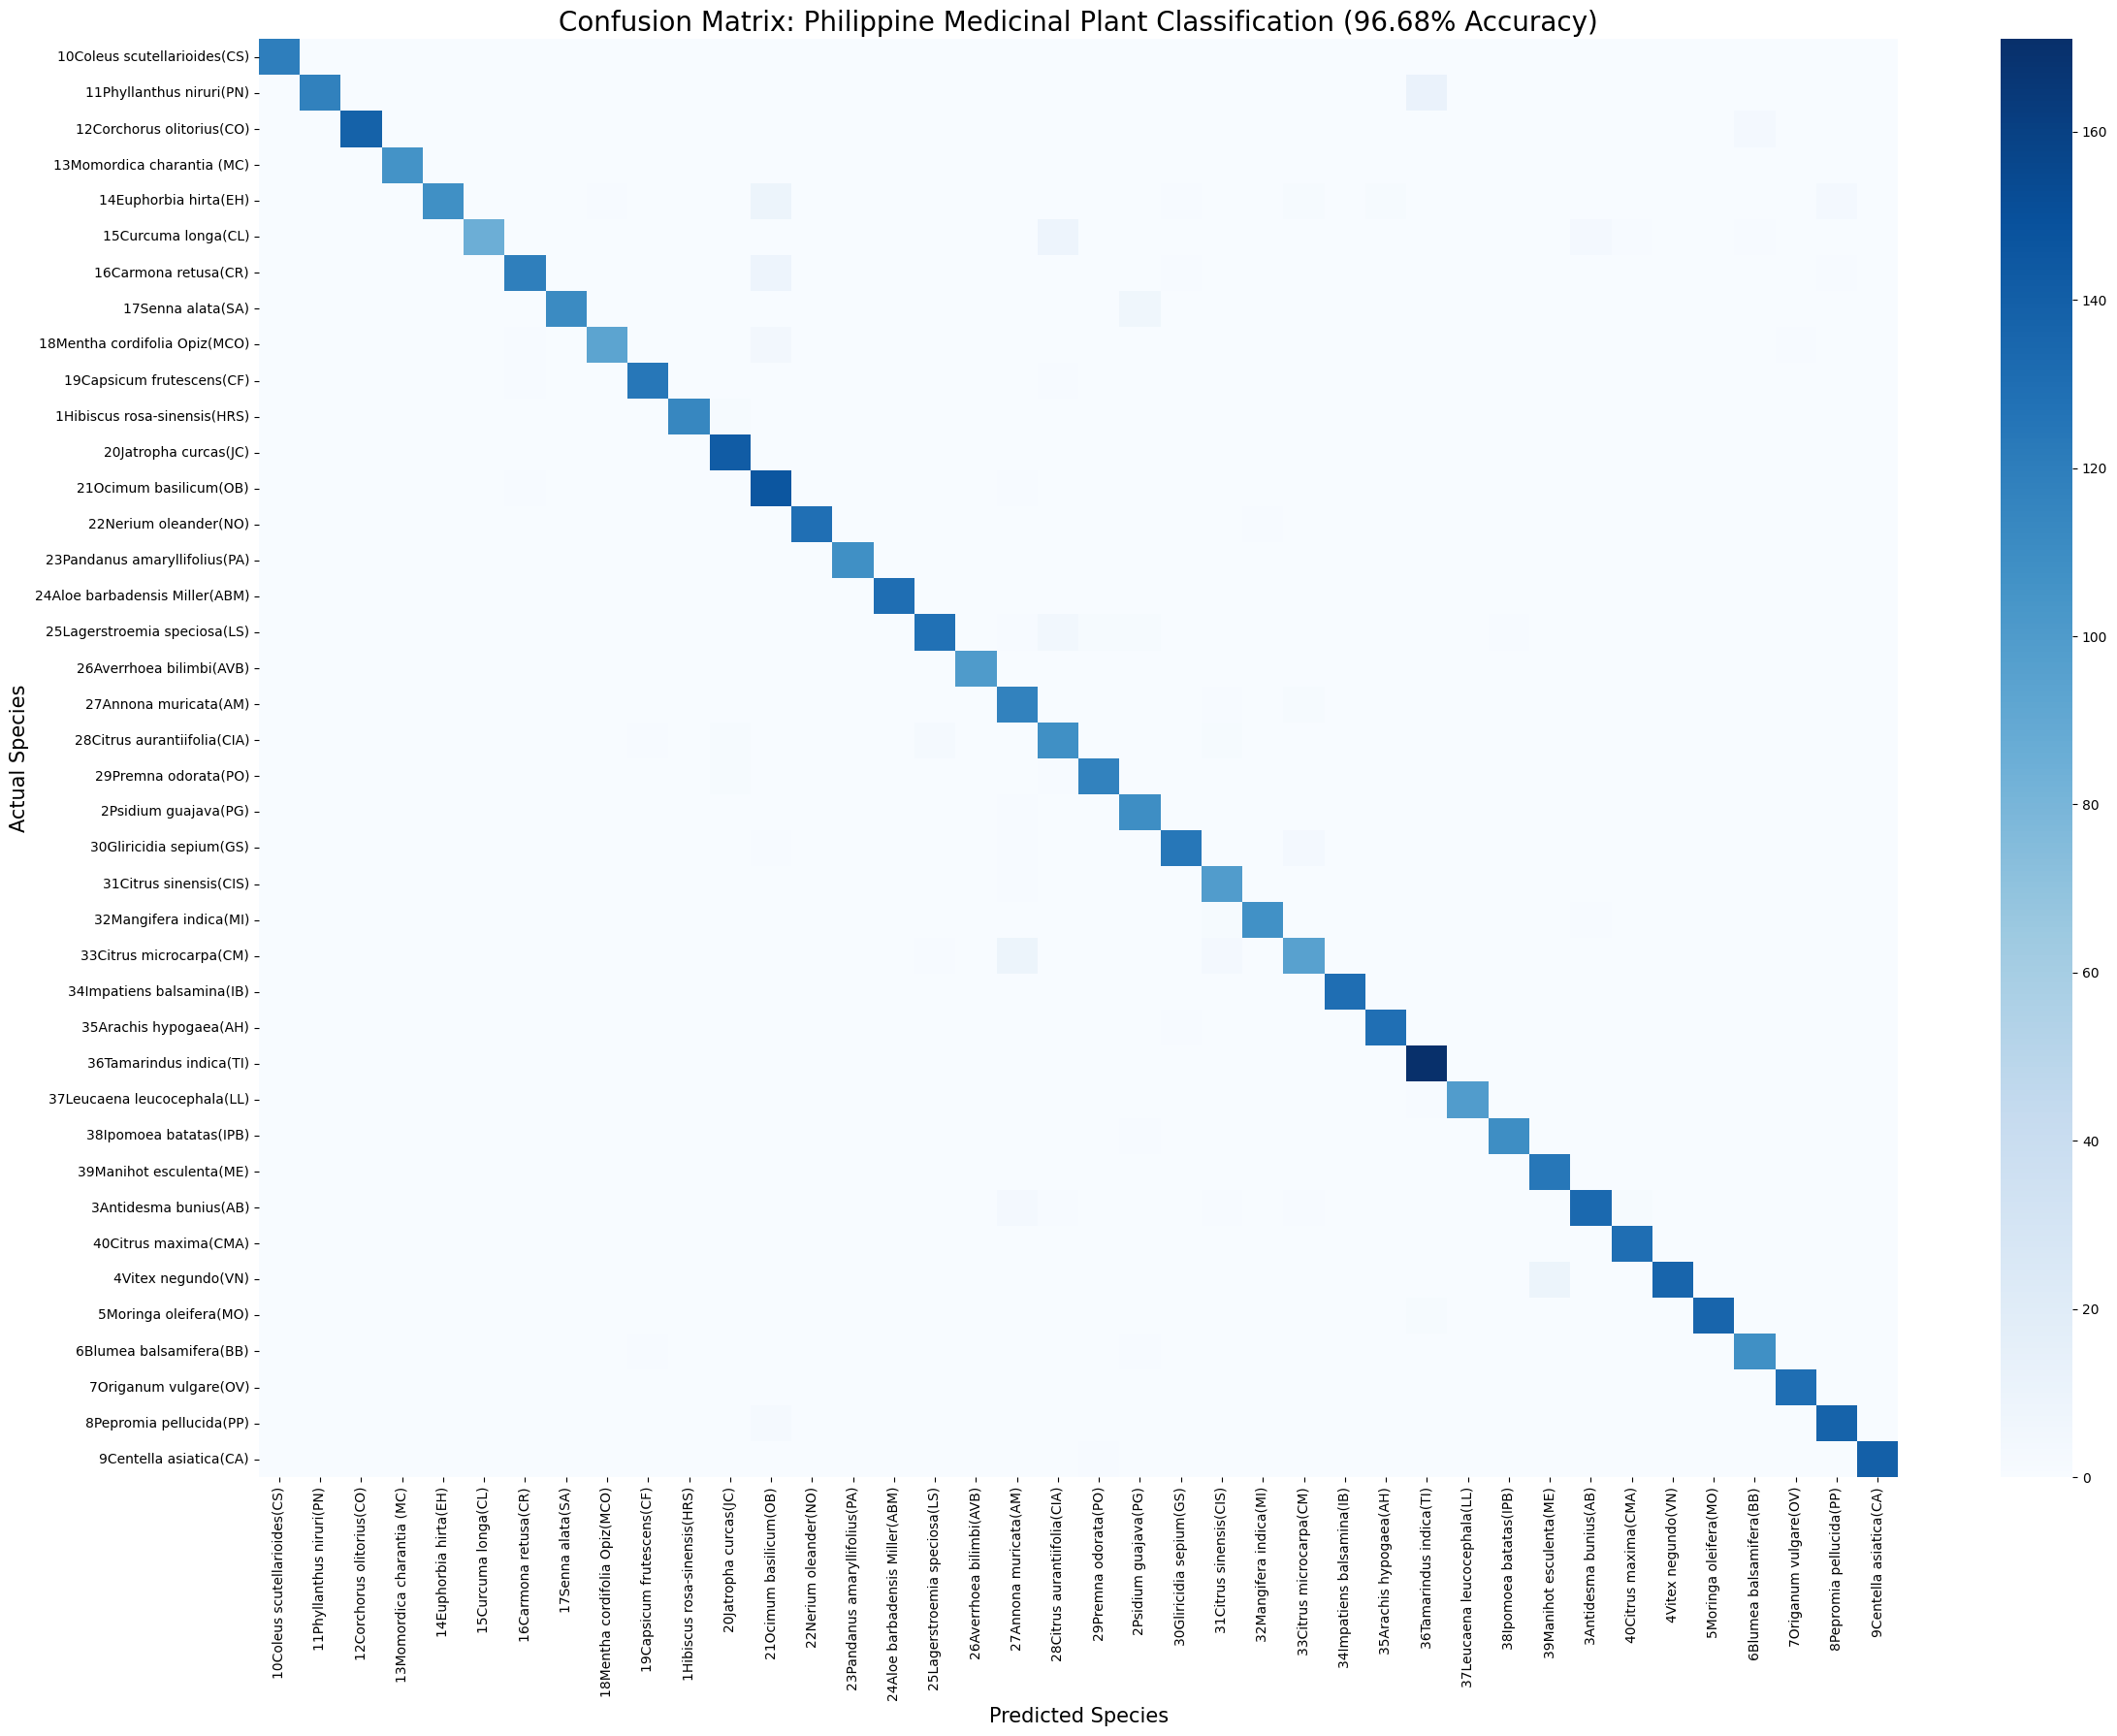

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import tensorflow as tf

# 1. Re-initialize the Validation Generator to force shuffle=False
# This ensures every image matches its label perfectly
eval_datagen = ImageDataGenerator(rescale=1./255)
eval_generator = eval_datagen.flow_from_directory(
    '/content/dataset/Philippine Medicinal Plant Leaf Dataset', # Use your actual path here
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # This is the most important part
)

# 2. Load your best saved model
model = tf.keras.models.load_model('herbal_ph_best_model.h5')

# 3. Predict again with the clean generator
print("📊 Re-running evaluation with synchronized labels...")
Y_pred = model.predict(eval_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = eval_generator.classes

# 4. Final Calculation
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print("\n" + "="*40)
print(" ⭐ TRUE INTELLIGENT SYSTEM METRICS")
print("="*40)
print(f" Final Accuracy:  {acc*100:.2f}%")
print(f" Precision Score: {prec*100:.2f}%")
print(f" Recall Score:    {rec*100:.2f}%")
print(f" F1-Score:        {f1*100:.2f}%")
print("="*40)

In [ ]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Freeze all layers EXCEPT the last 20
# This allows the model to learn fine textures (veins, edges) without forgetting general shapes
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. Re-compile with a VERY low learning rate (1e-5)
# This prevents the model from 'crashing' or losing its current knowledge
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train for only 5 more epochs
print("🔧 Sharpening the model's detection for similar leaves...")
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

🔧 Sharpening the model's detection for similar leaves...
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8912 - loss: 0.3569
Epoch 1: val_accuracy did not improve from 0.92188
125/125 ━━━━━━━━━━━━━━━━━━━━ 688s 5s/step - accuracy: 0.8986 - loss: 0.3222 - val_accuracy: 0.9008 - val_loss: 0.2893
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9012 - loss: 0.3189
Epoch 2: val_accuracy improved from 0.92188 to 0.92409, saving model to herbal_ph_best_model.h5



Epoch 2: finished saving model to herbal_ph_best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 703s 6s/step - accuracy: 0.9066 - loss: 0.2974 - val_accuracy: 0.9241 - val_loss: 0.2266
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9025 - loss: 0.2932
Epoch 3: val_accuracy did not improve from 0.92409
125/125 ━━━━━━━━━━━━━━━━━━━━ 659s 5s/step - accuracy: 0.9066 - loss: 0.2917 - val_accuracy: 0.9079 - val_loss: 0.2731
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9026 - loss: 0.3075
Epoch 4: val_accuracy did not improve from 0.92409
125/125 ━━━━━━━━━━━━━━━━━━━━ 704s 5s/step - accuracy: 0.9053 - loss: 0.2950 - val_accuracy: 0.9211 - val_loss: 0.2682
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8999 - loss: 0.3245
Epoch 5: val_accuracy did not improve from 0.92409
125/125 ━━━━━━━━━━━━━━━━━━━━ 647s 5s/step - accuracy: 0.9079 - loss: 0.3018 - val_accuracy: 0.9200 - val_loss: 0.2617
